# **Kaggle Challenge 2: Đề tài dự báo giá nhà.**
# **PHẦN 4: XÂY DỰNG MÔ HÌNH MÁY HỌC ĐỂ DỰ ĐOÁN GIÁ NHÀ**

## 1. Định nghĩa vấn đề
+ **Mô tả**:
   - Dự báo giá nhà dựa trên 79 tính chất của dataset nhà ở tại Ames, Iowa.
   - Dữ liệu đầu vào gồm 3 file:
      * train_processed.pkl: Dữ liệu từ tập train đã được xử lý ở phần 3.
      * test_processed.pkl: Dữ liệu từ tập  test đã được xử lý ở phần 3.
	  * train_y_processed.pkl: Dữ liệu chứa biến mục tiêu đã được xử lý ở phần 3.

+ **Mục tiêu**:
   - Dự đoán giá nhà bằng các mô hình máy học.
   - Đánh giá, cải tiến mô hình máy học. 
   - Xuất ra kết quả để submit lên Kaggle.


## 2. Chuẩn bị                

### 2.1. Import các thư viện cần thiết

In [1]:
# Load libraries
from IPython import display
import numpy as np
import pickle

import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

# model selection
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, KFold

# algorithms
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, LinearRegression
import sklearn

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.neural_network import MLPRegressor

# metrics
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# Hiển thị tối đa 200 cột
pd.set_option('display.max_columns', 200)

### 2.2. Đọc dataset train và test từ dataset đã xử lý trong phần dọn dẹp dữ liệu
Đọc các file .pkl trong thư mục /clean/data

In [2]:
train_data = pd.DataFrame(pd.read_pickle("../preprocessing/data/train_processed.pkl"))
test_data = pd.DataFrame(pd.read_pickle("../preprocessing/data/test_processed.pkl"))
train_y_data = pd.DataFrame(pd.read_pickle("../preprocessing/data/train_y_processed.pkl")).squeeze() # Chuyển về 1 chiều

### 2.3. Kiểm tra dữ liệu dataset train và test

In [3]:
train_data.head()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

,MSSubClass,LotFrontage,LotArea,LotShape,LandContour,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,YrSold,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,PavedDrive_P,PavedDrive_Y,Alley_None,Alley_Pave,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Utilities_NoSeWa,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,...,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,MoSold_sin,MoSold_cos,TotalSF,TotalRooms,TotalBath,MasVnrAreaBinary,BsmtFinSF1Binary,BsmtFinSF2Binary,BsmtUnfSFBinary,TotalBsmtSFBinary,1stFlrSFBinary,2ndFlrSFBinary,LowQualFinSFBinary,WoodDeckSFBinary,OpenPorchSFBinary,EnclosedPorchBinary,3SsnPorchBinary,ScreenPorchBinary,PoolAreaBinary,MiscValBinary,GarageAreaBinary,GarageCarsBinary,FireplacesBinary,FullBathBinary,HalfBathBinary,BsmtFullBathBinary,BsmtHalfBathBinary
0,60,-0.257516,-0.267660,3,3,2,7,5,0.949275,0.883333,-0.032711,2,2,4,3,1,6,0.183881,1,0.0,-1.183483,-0.332384,4,-0.524119,0.243325,0.0,0.342891,1,0,2,1,3,1,2,8,7,0,0,0.936364,2,2,0.293757,3,3,0.000000,-0.030571,0.000000,0.0,0.0,0.0,0,0.0,2008,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.660254e-01,5.000000e-01,-0.613178,11,3.5,1,1,0,1,1,1,1,0,0,1,0,0,0,0,0,1,1,0,1,1,1,0
1,20,0.464671,0.029682,3,3,2,6,8,0.753623,0.433333,0.000000,1,2,4,3,4,5,0.568045,1,0.0,-0.590948,0.476762,4,0.327547,0.000000,0.0,-0.327743,0,1,2,0,3,1,1,6,7,1,3,0.690909,2,2,-0.120278,3,3,

In [4]:
test_data.head()

,MSSubClass,LotFrontage,LotArea,LotShape,LandContour,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,YrSold,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,PavedDrive_P,PavedDrive_Y,Alley_None,Alley_Pave,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Utilities_NoSeWa,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,...,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,MoSold_sin,MoSold_cos,TotalSF,TotalRooms,TotalBath,MasVnrAreaBinary,BsmtFinSF1Binary,BsmtFinSF2Binary,BsmtUnfSFBinary,TotalBsmtSFBinary,1stFlrSFBinary,2ndFlrSFBinary,LowQualFinSFBinary,WoodDeckSFBinary,OpenPorchSFBinary,EnclosedPorchBinary,3SsnPorchBinary,ScreenPorchBinary,PoolAreaBinary,MiscValBinary,GarageAreaBinary,GarageCarsBinary,FireplacesBinary,FullBathBinary,HalfBathBinary,BsmtFullBathBinary,BsmtHalfBathBinary
0,20,0.464671,0.475099,3,3,2,5,6,0.644928,0.183333,0.000000,1,2,3,3,1,3,-0.300515,2,-0.797025,-0.637935,-0.270025,2,-0.423937,0.000000,0.0,-1.083647,0,0,1,0,2,1,1,5,7,0,0,0.554545,1,1,0.972317,3,3,-0.288436,0.000000,0.0,0.0,-0.912966,0.0,0,0.000000,2010,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.224647e-16,-1.000000e+00,-0.693962,6,1.0,0,1,1,1,1,1,0,0,1,0,0,0,1,0,0,1,1,0,1,0,0,0
1,20,0.507940,0.952946,2,3,2,6,6,0.623188,0.133333,-0.587195,1,2,3,3,1,5,0.499805,1,0.000000,-0.258563,0.584609,2,0.441062,0.000000,0.0,-0.213560,0,0,1,1,3,1,2,6,7,0,0,0.527273,1

In [5]:
train_y_data.head()

0    0.493727
1    0.215600
2    0.633052
3   -0.305049
4    0.857766
Name: SalePrice, dtype: float64

In [6]:
print("Số cột null trong train: ", train_data.isnull().sum().gt(0).sum())
print("Số cột null trong test: ", test_data.isnull().sum().gt(0).sum())

Số cột null trong train:  0
Số cột null trong test:  0


In [7]:
train_data.dtypes.value_counts()

float64    194
int64       54
Name: count, dtype: int64

In [8]:
test_data.dtypes.value_counts()

float64    194
int64       54
Name: count, dtype: int64

## 3. Thiết lập các tham số mặc định

In [ ]:
parameters = {}
parameters["random_state"] = 42
parameters["k_fold"] = 10

## 4. Huấn luyện mô hình

### 4.1. Chia K-Fold 
**K-Fold Cross Validation** là kỹ thuật đánh giá mô hình học máy bằng cách chia dữ liệu thành **K phần (fold)** có kích thước gần bằng nhau.  
Quá trình huấn luyện và kiểm tra sẽ được lặp lại **K lần**, mỗi lần sử dụng một fold khác nhau làm **tập kiểm tra (validation)**, và **K-1 fold còn lại** làm **tập huấn luyện (training)**.


In [10]:
kf = KFold(n_splits=parameters["k_fold"], shuffle=True, random_state=parameters["random_state"])

### 4.2. Chọn các model để train.
#### Logistic Regression
**Linear Regression** là mô hình hồi quy cơ bản và phổ biến nhất, được sử dụng để **dự đoán giá trị liên tục** dựa trên mối quan hệ **tuyến tính** giữa các biến đầu vào (độc lập) và biến đầu ra (phụ thuộc).

- Mục tiêu của mô hình là **tìm đường thẳng (hoặc siêu phẳng trong không gian nhiều chiều)** sao cho sai số giữa giá trị dự đoán và giá trị thực tế là nhỏ nhất.

#### Random Forest
**Random Forest** là mô hình **ensemble learning** (học tập hợp) dựa trên nhiều **cây quyết định (Decision Tree)**.  
Kết quả cuối cùng là **trung bình** (hồi quy) hoặc **bỏ phiếu đa số** (phân loại) từ nhiều cây con.

- Tăng cường độ chính xác và giảm overfitting nhờ cơ chế **bagging** (bootstrap aggregation).  
- Mỗi cây được huấn luyện trên một **mẫu dữ liệu ngẫu nhiên** và chỉ dùng một phần các đặc trưng.  

#### XGBoost
**XGBoost (Extreme Gradient Boosting)** là một mô hình **boosting** mạnh mẽ, xây dựng cây liên tiếp để **sửa lỗi** của các cây trước.

- Mỗi cây mới được huấn luyện dựa trên **gradient của hàm mất mát**, giúp giảm lỗi nhanh.  
- Hỗ trợ regularization (L1, L2) → giảm overfitting.  
- Tối ưu hiệu suất với **song song hóa** và **xử lý thiếu dữ liệu tự động**.  


#### CatBoost
**CatBoost (Categorical Boosting)** là thuật toán boosting do Yandex phát triển, đặc biệt tối ưu cho **biến phân loại (categorical features)**.

- Tự động **mã hóa biến phân loại** bằng cơ chế **target statistics** an toàn (không gây rò rỉ dữ liệu).  
- Dựa trên **Ordered Boosting** giúp giảm overfitting so với gradient boosting thông thường.  
- Là mô hình mạnh, **ít cần tiền xử lý dữ liệu** và **dễ dùng**.  

#### Support Vector Machine (SVM)
**SVM** tìm **siêu phẳng (hyperplane)** tối ưu để phân tách các lớp dữ liệu sao cho **khoảng cách biên (margin)** giữa các lớp là lớn nhất.

- Dữ liệu không tuyến tính có thể được ánh xạ sang không gian cao hơn bằng **kernel trick** (RBF, polynomial,...).  


#### K-Nearest Neighbours (KNN)
**KNN** là thuật toán **phi tham số (non-parametric)**, không có quá trình huấn luyện thực sự.  
Khi dự đoán, mô hình tìm **K điểm gần nhất** (theo khoảng cách Euclid hoặc Manhattan) và:

- Với hồi quy: lấy **trung bình giá trị** của K láng giềng.  
- Với phân loại: lấy **nhãn phổ biến nhất** trong K láng giềng.

#### Decision Tree
**Decision Tree** là mô hình dự đoán dựa trên **các câu hỏi điều kiện (if-else)** được tổ chức dạng cây.

- Mỗi nút (node) chia dữ liệu theo **đặc trưng** để giảm độ hỗn loạn (entropy, Gini, variance).  
- Cành (branch) biểu diễn điều kiện, lá (leaf) chứa kết quả dự đoán.  



In [11]:
models = {}
# Linear Regression
models["Linear Regression"] = LinearRegression(n_jobs=-1)

models["Random Forest"] = RandomForestRegressor(
    random_state=parameters["random_state"],
    n_jobs=-1,
    max_depth=8,             # tăng độ sâu một chút cho dữ liệu phức tạp
    min_samples_leaf=2,
    n_estimators=500,         # nhiều cây hơn thường cho kết quả ổn định hơn
)

models["Gradient Boosting"] = GradientBoostingRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=5,
    min_samples_leaf=2,
    subsample=0.85,
    max_features='sqrt',
    random_state=parameters["random_state"]
)


# XGBoost Regressor
models["XGBoost"] = XGBRegressor(
    max_depth=8,
    learning_rate=0.05,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=parameters["random_state"],
    n_jobs=-1,
    eval_metric='rmse'        # metric chuẩn cho hồi quy
)

# Histogram Gradient Boosting Regressor (HGBoost)
models["HGBoost"] = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.05,
    max_iter=500,
    random_state=parameters["random_state"]
)

# LightGBM
models["LightGBM"] = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=3,
    random_state=parameters["random_state"],
    n_jobs=-1,
)

# Support Vector Regressor (SVR)
models["SVM"] = SVR(
    kernel='poly',
    C=50000,
    epsilon=0.05               # biên dung sai cho hồi quy epsilon-SVR
)

# CatBoost Regressor
models["CatBoost"] = CatBoostRegressor(
    depth=8,
    l2_leaf_reg=3,
    subsample=0.8,
    learning_rate=0.05,
    iterations=1000,
    random_seed=parameters["random_state"],
    loss_function='RMSE',     # đúng loss cho hồi quy
    eval_metric='RMSE',
    verbose=0,
    allow_writing_files=False
)

# K-Nearest Neighbors Regressor
models["KNN"] = KNeighborsRegressor(
    n_neighbors=5,
    weights='distance',
    n_jobs=-1
)

# Decision Tree Regressor
models["Decision Tree"] = DecisionTreeRegressor(
    max_depth=11,
    random_state=parameters["random_state"],
    min_samples_leaf=3
)


In [12]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from scipy.stats import uniform, loguniform
import numpy as np

param_distributions = {
    'kernel': ['rbf', 'poly'],
    'C': loguniform(10, 60000),      # phạm vi rộng cho C (10 → 100000)
    'epsilon': uniform(0.01, 0.3),  # khoảng dung sai
    'gamma': loguniform(1e-4, 1e0),  # hệ số cho kernel RBF
	'degree': [2, 3, 4]
}


# # Thiết lập RandomizedSearch
# random_search = RandomizedSearchCV(
#     estimator=SVR(),
#     param_distributions=param_distributions,
#     n_iter=3,                           # số lượng tổ hợp tham số cần thử
#     scoring='neg_root_mean_squared_error',
#     cv=2,
#     verbose=2,
#     random_state=parameters["random_state"],
#     n_jobs=-1
# )

# # Huấn luyện
# random_search.fit(train_data, train_y_data)

# # In kết quả
# print("==== Best Parameters ====")
# print(random_search.best_params_)
# print("Best CV RMSE:", -random_search.best_score_)



### 4.3. Thực hiện huấn luyện và đánh giá mô hình
Mô hình được đánh giá dựa trên 3 tiêu chí chính là:

**MAE — Mean Absolute Error:**
	$$
	\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
	$$

Trong đó:
- $n$: số lượng mẫu dữ liệu.
- $y_i$: giá trị thực tế của mẫu thứ $ i $.  
- $\hat{y}_i$: giá trị dự đoán của mẫu thứ $ i $.

**Root Mean Squared Error (RMSE):**

$$
\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }
$$

Trong đó:
- $ n $: số lượng mẫu dữ liệu.
- $ y_i $: giá trị thực tế của mẫu thứ $ i $. 
- $ \hat{y}_i $: giá trị dự đoán của mẫu thứ $ i $.

**R² — Coefficient of Determination:**
	$$
	R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
	$$

Trong đó: 
- $y_i$: giá trị thực tế của mẫu thứ $ i $.  
- $ \hat{y}_i $: giá trị dự đoán của mẫu thứ $ i $. 
- $ \bar{y} $: giá trị trung bình của toàn bộ tập $ y $.
- Tử số: tổng bình phương sai số (Residual Sum of Squares - RSS).  
- Mẫu số: tổng bình phương tổng thể (Total Sum of Squares - TSS).

In [ ]:
# Khởi tạo lưu kết quả
results = {name: {'r2': [], 'rmse': [], 'mae': []} for name in models.keys()}
evals_result = {}

# KFold chia dữ liệu
for fold, (train_index, val_index) in enumerate(kf.split(train_data), 1):
    X_train_fold, X_val_fold = train_data.iloc[train_index], train_data.iloc[val_index]
    y_train_fold, y_val_fold = train_y_data.iloc[train_index], train_y_data.iloc[val_index]
    
    print(f"\n===== Fold {fold}/{kf.get_n_splits()} =====")

    for name, model in models.items():
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)

        # Tính các chỉ số đánh giá hồi quy
        r2 = r2_score(y_val_fold, y_pred)
        rmse = root_mean_squared_error(y_val_fold, y_pred)
        mae = mean_absolute_error(y_val_fold, y_pred)

        results[name]['r2'].append(r2)
        results[name]['rmse'].append(rmse)
        results[name]['mae'].append(mae)
        
		# In log
        print(f"Model: {name}")
        print(f"  R²   = {r2:.4f}")
        print(f"  RMSE = {rmse:.4f}")
        print(f"  MAE  = {mae:.4f}")

# Hiển thị kết quả trung bình
print("\n\n-------------KẾT QUẢ TRUNG BÌNH-------------")
for name in models.keys():
    r2_mean = np.mean(results[name]['r2'])
    rmse_mean = np.mean(results[name]['rmse'])
    mae_mean = np.mean(results[name]['mae'])
    print(f"{name} Average Results:")
    print(f"  R2 Score: {r2_mean:.4f}")
    print(f"  RMSE:      {rmse_mean:.4f}")
    print(f"  MAE:      {mae_mean:.4f}")
    print("-" * 30)



===== Fold 1/10 =====
Model: Linear Regression
  R²   = 0.9375
  RMSE = 0.2220
  MAE  = 0.1635
Model: Random Forest
  R²   = 0.9038
  RMSE = 0.2753
  MAE  = 0.1860
Model: Gradient Boosting
  R²   = 0.9267
  RMSE = 0.2403
  MAE  = 0.1600
Model: XGBoost
  R²   = 0.9210
  RMSE = 0.2496
  MAE  = 0.1645
Model: HGBoost
  R²   = 0.9204
  RMSE = 0.2504
  MAE  = 0.1713
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3531
[LightGBM] [Info] Number of data points in the train set: 1314, number of used features: 170
[LightGBM] [Info] Start training from score 0.047755
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

**Nhận xét**:
- Mô hình CatBoost và GradientBoost có hiệu suất học tốt nhất dựa trên 3 tiêu chí chính.
- Mô hình DecisionTree có hiệu suất học kém nhất dựa trên 3 tiêu chí chính.

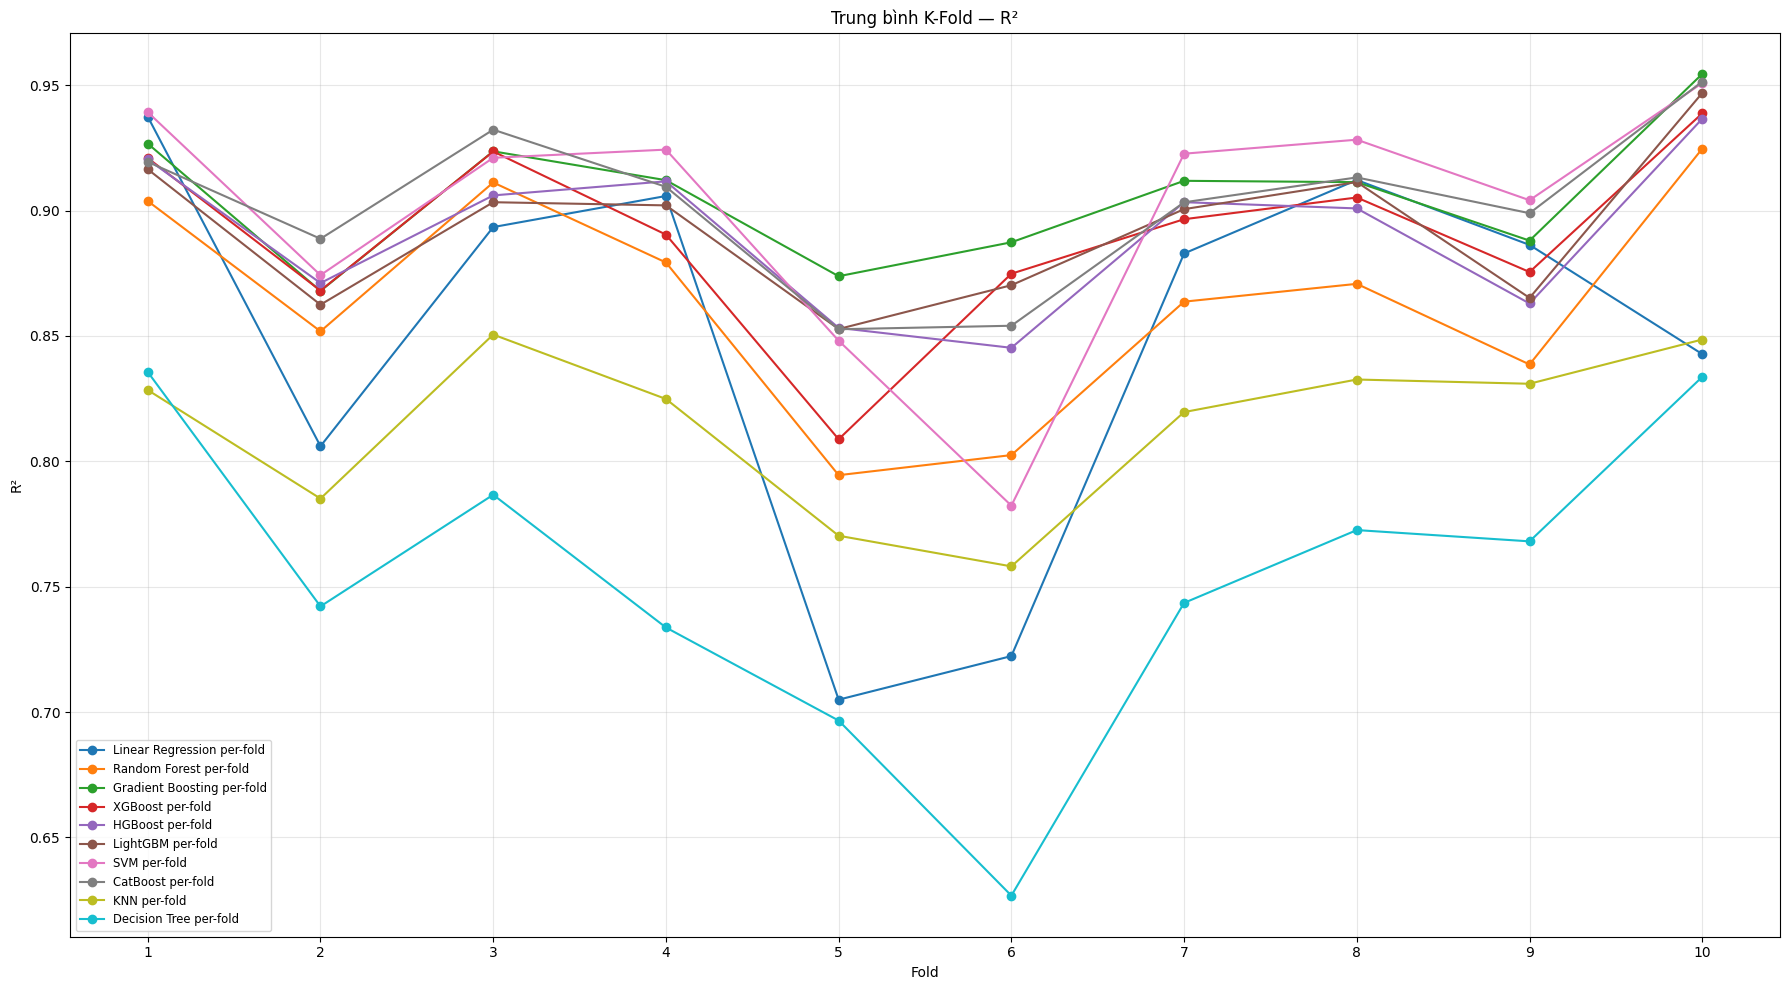

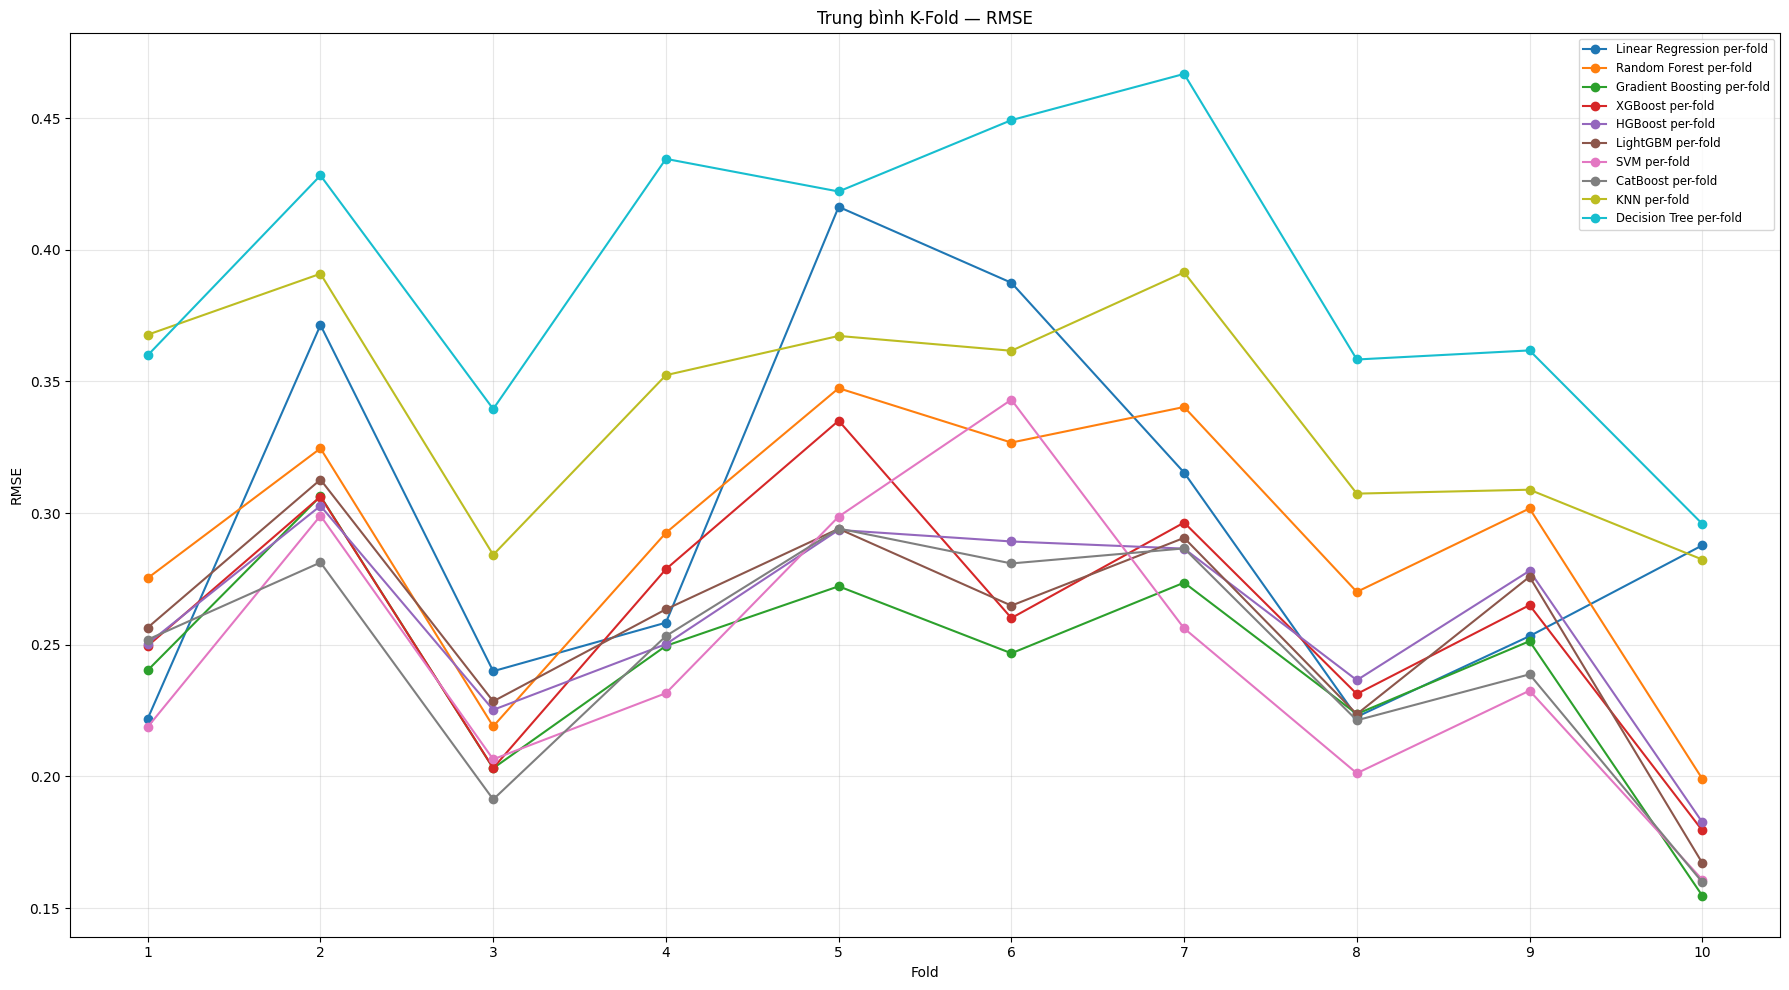

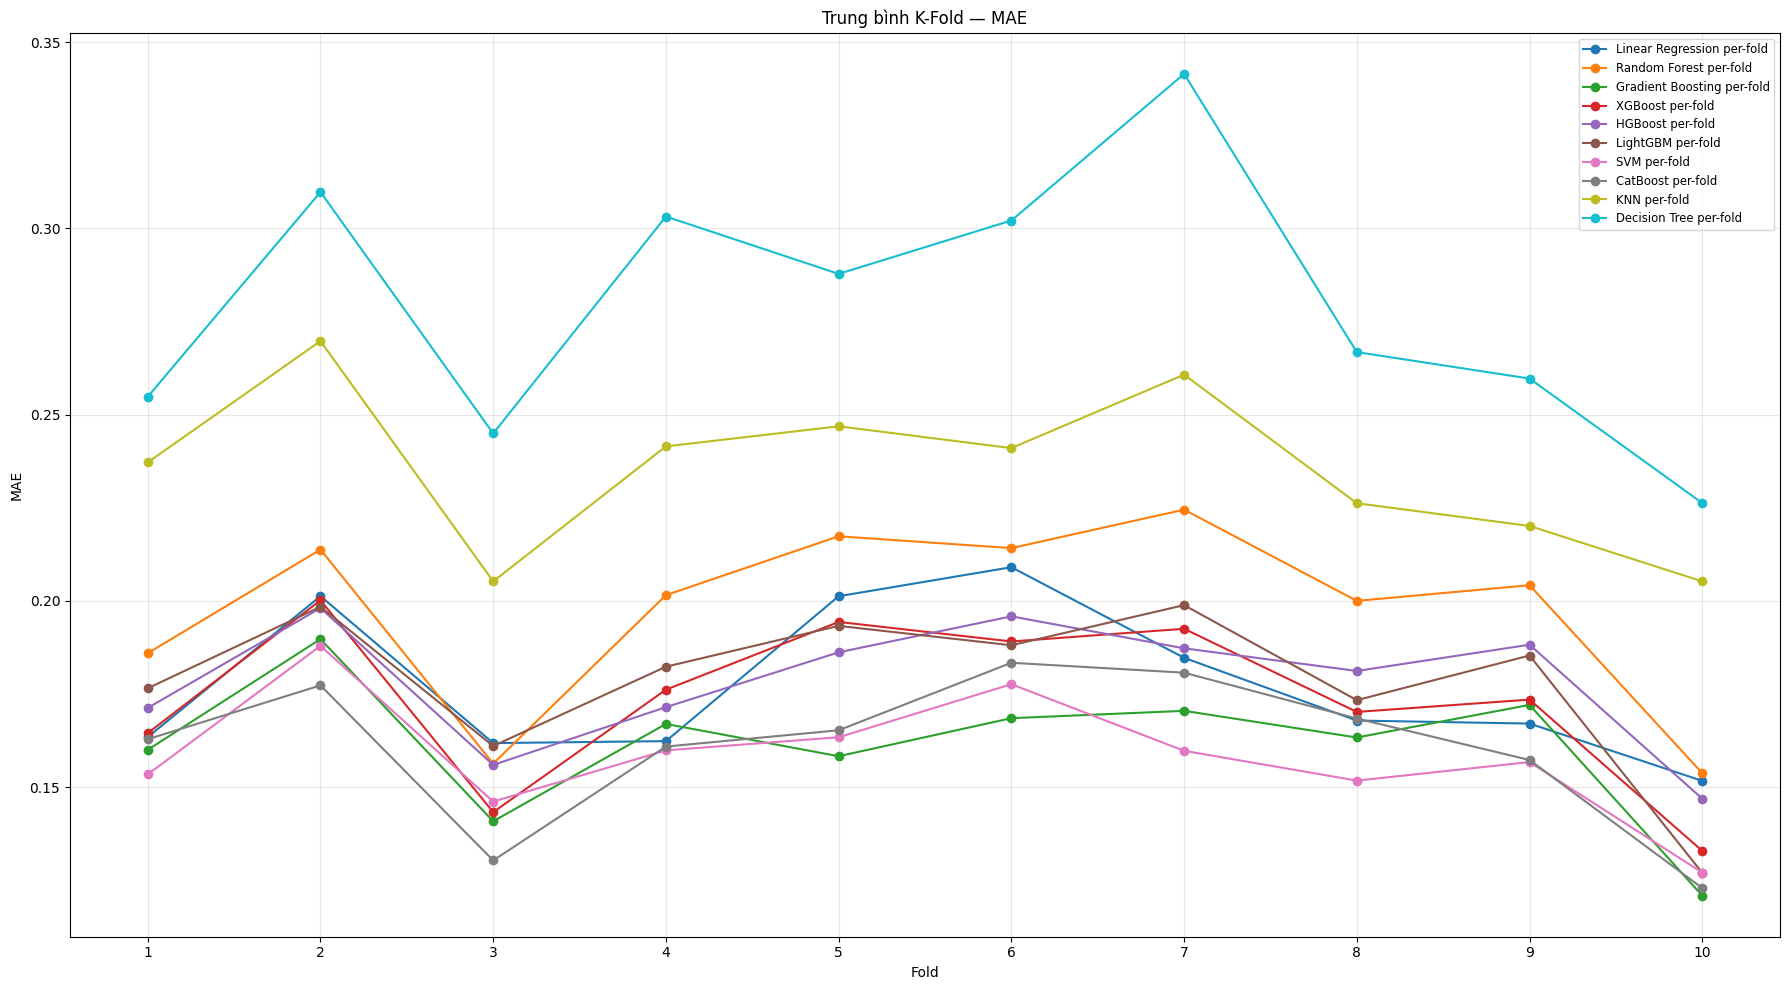

In [19]:
model_names = list(results.keys())
n_folds = len(next(iter(results.values()))['r2'])
folds = np.arange(1, n_folds + 1)

# Hàm vẽ cho một metric
def plot_metric(metric_key, ylabel, ylim=None):
    plt.figure(figsize=(18, 10))
    for name in model_names:
        vals = np.array(results[name][metric_key])
        # Giá trị tại từng fold
        plt.plot(folds, vals, marker='o', label=f"{name} per-fold")
        
    plt.xlabel("Fold")
    plt.ylabel(ylabel)
    plt.xticks(folds)
    if ylim is not None:
        plt.ylim(ylim)
    plt.grid(alpha=0.3)
    plt.legend(loc='best', fontsize='small')
    plt.title(f"Trung bình K-Fold — {ylabel}")
    plt.tight_layout()
    plt.show()

# Vẽ R² (cao là tốt)
plot_metric('r2', 'R²')

# Vẽ RMSE (thấp là tốt)
plot_metric('rmse', 'RMSE')

# Vẽ MAE (thấp là tốt)
plot_metric('mae', 'MAE')

# **Kết thúc**